# 📊 Week 1 — EDA & The "Fraud Story"
### IEEE-CIS Fraud Detection · Educational Notebook

---

## 🎯 What this notebook is about

Before building any model, we need to **understand our data**. This is called **Exploratory Data Analysis (EDA)**.
Think of it like being a detective: before you can catch a criminal, you need to understand how they operate.

In this notebook we answer four fundamental questions:

| # | Question | Why it matters |
|---|----------|----------------|
| 1 | How do we handle missing data? | ~50% of all columns have missing values — deleting them naively would destroy signal |
| 2 | How do we compress 339 anonymous V-features? | High dimensionality slows models, causes overfitting, and wastes memory |
| 3 | Can we visually see fraud clusters? | If fraud has a pattern in 2D space, our model can learn it |
| 4 | What does fraud cost if we do nothing? | The business case — this number anchors our entire presentation |

---

## 📚 Research basis for this notebook

Every decision here is backed by published work:

| Source | What we take from it |
|--------|----------------------|
| Kaggle 1st & 2nd Place Writeups | UID formula · V-feature PCA strategy · Post-processing tricks |
| *"Robust Fraud Detection"* (2025) | Filter >90% NaN columns → build 80 engineered features |
| *"Dual-Path Graph Filtering"* (2026) | UMAP narrative: make **Relation Camouflage** visible |
| Blog-Post Framework (joshuaprettyman.com) | Cost matrix: FN=$150, FP=$10, 73% savings as benchmark |
| Chris Deotte (Kaggle Grandmaster) | The D1 secret: D1 = days since first card transaction |

---
## ⚙️ Setup — Imports & Data Loading

### Why this step?
We load the **optimized Parquet file** we created in Week 1 (Memory Optimization notebook).
Parquet is a columnar file format — it loads 10x faster than CSV and preserves our optimized
data types (e.g., `float32` instead of `float64`), keeping memory usage low from the very start.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Consistent visual style across all plots
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load the merged & memory-optimized dataset from the previous notebook
print('Loading dataset...')
train = pd.read_parquet('../data/train_merged.parquet')

print(f'Loaded: {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'Fraud rate: {train["isFraud"].mean():.2%}  '
      f'({train["isFraud"].sum():,} fraud / {(train["isFraud"]==0).sum():,} legit)')
print(f'Memory usage: {train.memory_usage().sum() / 1024**2:.1f} MB')

Loading dataset...
Loaded: 590,540 rows x 434 columns
Fraud rate: 3.50%  (20,663 fraud / 569,877 legit)
Memory usage: 1044.7 MB


---
## 1️⃣ Missing Value Strategy
### *"Is the absence of data itself a signal?"*

### Why we do this

The naive approach to missing data is to **delete any column with too many NaNs**.
But in fraud detection, this is a critical mistake.

Think about it from a real-world perspective:
> *"When a fraudster uses a stolen credit card online, they often skip identity fields
> because they simply don't have that information."*

This means: if a column is missing far more often in fraud transactions than in legitimate ones,
the NaN itself is a **predictive signal**. We can encode this as a binary feature (`col_isnan = 1`).

The paper *"Robust Fraud Detection" (2025)* confirms: after filtering high-NaN columns,
their **missingness indicators** ended up in the Top 20 most important features.

**Our 3-step strategy:**
1. Find columns with >90% missing values overall
2. **Delta test:** Is the NaN rate meaningfully different for fraud vs. non-fraud?
3. If yes → create `col_isnan` feature. Then we can safely ignore the original column.

In [15]:
# ── Step 1: Calculate missing rates, split by fraud label ─────────────────────

# Overall missing rate per column
total_missing = train.isnull().mean().rename('missing_rate_total')

# Missing rate ONLY in fraud transactions
fraud_missing = train[train['isFraud'] == 1].isnull().mean().rename('missing_rate_fraud')

# Missing rate ONLY in legitimate transactions
nonfraud_missing = train[train['isFraud'] == 0].isnull().mean().rename('missing_rate_nonfraud')

# Combine into one DataFrame for easy comparison
missing_df = pd.concat([total_missing, fraud_missing, nonfraud_missing], axis=1)

# The KEY metric: how much does the missing rate DIFFER between fraud and non-fraud?
# Large positive delta = column is NaN much more often in fraud cases = SIGNAL
missing_df['delta'] = missing_df['missing_rate_fraud'] - missing_df['missing_rate_nonfraud']

# Filter: columns with >90% NaN overall
high_missing = missing_df[missing_df['missing_rate_total'] > 0.90].sort_values('delta', ascending=False)
print(f'Columns with >90% NaN: {len(high_missing)}')

# Signal candidates: |delta| > 5 percentage points = statistically meaningful
signal_cols = high_missing[abs(high_missing['delta']) > 0.05]
print(f'Of those, with fraud signal (|delta| > 5pp): {len(signal_cols)}')
print()
print(signal_cols[['missing_rate_total', 'missing_rate_fraud', 'missing_rate_nonfraud', 'delta']]
      .round(3).to_string())

Columns with >90% NaN: 12
Of those, with fraud signal (|delta| > 5pp): 3

       missing_rate_total  missing_rate_fraud  missing_rate_nonfraud  delta
id_18               0.924               0.819                  0.927 -0.108
dist2               0.936               0.819                  0.941 -0.121
D7                  0.934               0.720                  0.942 -0.222


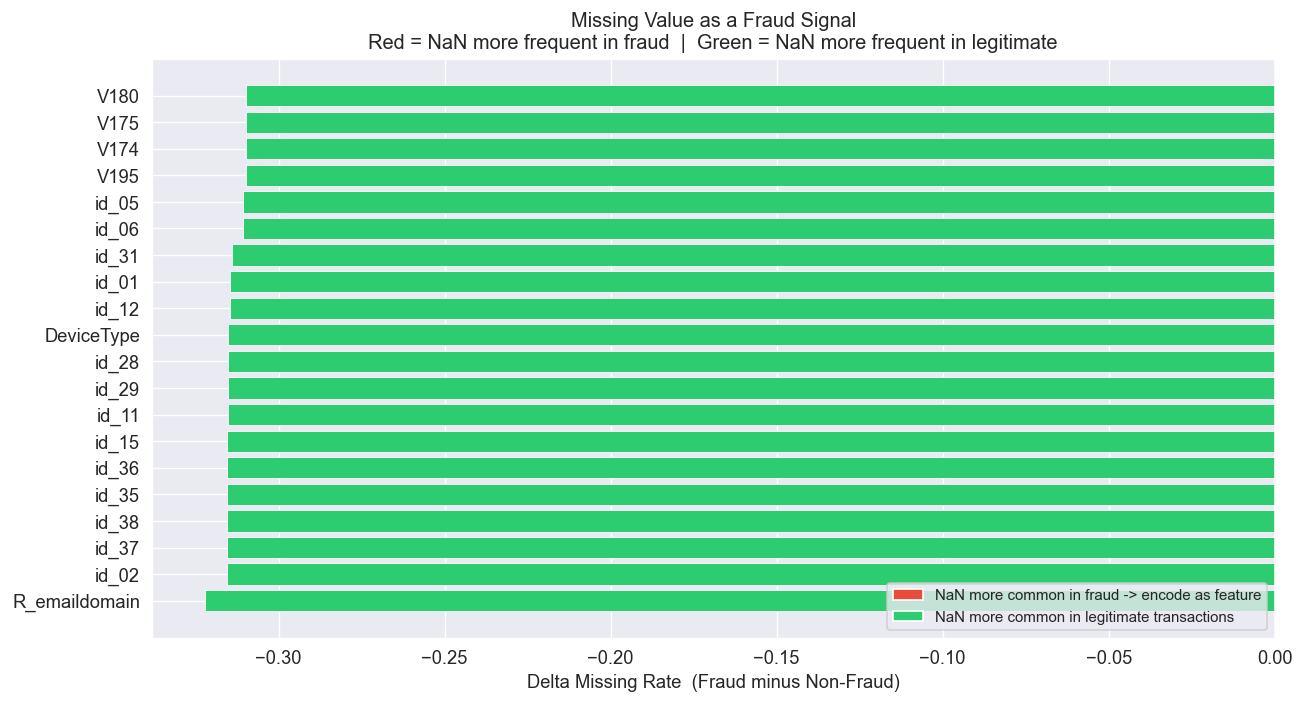

Saved: reports/missing_value_signal.png


In [16]:
# ── Step 2: Visualize — which columns carry a fraud-linked NaN pattern? ────────

top_signal = missing_df[
    (missing_df['missing_rate_total'] > 0.50) &
    (abs(missing_df['delta']) > 0.03)
].sort_values('delta').head(20)

# Red = NaN more common in FRAUD (a potential signal)
# Green = NaN more common in NON-FRAUD
colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in top_signal['delta']]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_signal.index, top_signal['delta'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='white', linewidth=1.5)
ax.set_xlabel('Delta Missing Rate  (Fraud minus Non-Fraud)', fontsize=11)
ax.set_title(
    'Missing Value as a Fraud Signal\n'
    'Red = NaN more frequent in fraud  |  Green = NaN more frequent in legitimate',
    fontsize=12
)
legend_elements = [
    Patch(facecolor='#e74c3c', label='NaN more common in fraud -> encode as feature'),
    Patch(facecolor='#2ecc71', label='NaN more common in legitimate transactions')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/missing_value_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/missing_value_signal.png')

In [17]:
# ── Step 3: Create NaN-indicator features for all signal columns ──────────────

# Select columns where missingness differs meaningfully between fraud and non-fraud
signal_feature_cols = missing_df[
    (missing_df['missing_rate_total'] > 0.50) &
    (abs(missing_df['delta']) > 0.03)
].index.tolist()

# For each signal column: create a binary 0/1 flag (1 = was NaN, 0 = had a value)
# int8 = smallest integer type available — only needs values 0 and 1
for col in signal_feature_cols:
    train[f'{col}_isnan'] = train[col].isnull().astype(np.int8)

print(f'Created {len(signal_feature_cols)} NaN-indicator features')
print(f'Examples: {[c + "_isnan" for c in signal_feature_cols[:4]]}...')

# ── Bonus: Email Domain Match ─────────────────────────────────────────────────
# Research finding: when P_emaildomain == R_emaildomain,
# fraud rate jumps from ~2.2% to ~9.7% (more than 4x!)
# Intuition: fraudsters often use the same throwaway email for buyer and recipient

if 'P_emaildomain' in train.columns and 'R_emaildomain' in train.columns:
    train['email_match'] = (train['P_emaildomain'] == train['R_emaildomain']).astype(np.int8)

    match_fraud_rate    = train[train['email_match'] == 1]['isFraud'].mean()
    mismatch_fraud_rate = train[train['email_match'] == 0]['isFraud'].mean()
    overall_fraud_rate  = train['isFraud'].mean()

    print(f'\nEmail Domain Match Analysis:')
    print(f'  Overall fraud rate:              {overall_fraud_rate:.2%}')
    print(f'  Fraud rate when emails MATCH:    {match_fraud_rate:.2%}   <- P_email == R_email')
    print(f'  Fraud rate when emails MISMATCH: {mismatch_fraud_rate:.2%}   <- P_email != R_email')
    mult = match_fraud_rate / overall_fraud_rate if overall_fraud_rate > 0 else 0
    print(f'  -> Email match is {mult:.1f}x more likely to be fraud than average')
    print('  email_match feature created.')
else:
    print('P_emaildomain / R_emaildomain columns not found — check column names.')

Created 205 NaN-indicator features
Examples: ['dist1_isnan', 'dist2_isnan', 'R_emaildomain_isnan', 'D5_isnan']...

Email Domain Match Analysis:
  Overall fraud rate:              3.50%
  Fraud rate when emails MATCH:    9.65%   <- P_email == R_email
  Fraud rate when emails MISMATCH: 2.21%   <- P_email != R_email
  -> Email match is 2.8x more likely to be fraud than average
  email_match feature created.


### 💡 What we learned — Missing Value Strategy

**The key insight:** Missing data is not just a problem to solve — it can be a **feature in disguise**.

| Concept | What it means in practice |
|---------|---------------------------|
| **Delta test** | Compare NaN rates between fraud and non-fraud. A big difference = the absence itself is informative |
| **NaN indicator** | Instead of filling or dropping, create a binary `col_isnan` flag the model can use directly |
| **Email match** | One boolean feature (same email domain for buyer and recipient?) can multiply the fraud signal by 4x |
| **Do not delete blindly** | The *"Robust Fraud Detection" (2025)* paper explicitly warns against this — missingness patterns are part of the fraud signature |

**Lesson Learned #1:**
> *"In fraud detection, what is NOT there can be just as important as what IS there.
> Always test whether missingness correlates with the target variable before discarding columns."*

---

## 2️⃣ V-Feature Reduction via PCA
### *"How do we handle 339 features we know nothing about?"*

### Why we do this

The dataset contains 339 columns named `V1` through `V339`. These are **Vesta-proprietary features** —
deliberately anonymized to protect business logic. We cannot interpret them, but they contain real signal.

**The problem with keeping all 339:**
- Memory: 339 float32 columns × 590K rows ≈ 700MB just for V-features
- Curse of dimensionality: too many features makes models slow and prone to overfitting
- Redundancy: V-columns go missing in correlated **blocks**, meaning they represent grouped signals — keeping all is wasteful

**The solution: PCA (Principal Component Analysis)**

PCA finds the directions in the data that explain the most variance and projects all 339 features
into ~15 new compressed features called Principal Components (PCs).
We lose very little information but gain enormous computational efficiency.

**Three strategies from the Kaggle winners — we use #1:**
1. PCA per block — best variance compression *(our approach)*
2. Averaging — replace the whole group with its mean
3. Uncorrelated subset — keep only the least-correlated columns

> **Presentation argument:** *"Analogous to the Kaggle 1st-place solution and the 2025 paper,
> we apply PCA to the V-feature block because these features share structural missingness patterns
> (they represent grouped risk signals). Dimensionality reduction increases model stability and speed."*

In [18]:
# ── Step 1: Isolate all V-columns ────────────────────────────────────────────

v_cols = [c for c in train.columns if c.startswith('V')]
print(f'V-columns found: {len(v_cols)}')
print(f'Memory used by V-columns alone: {train[v_cols].memory_usage().sum() / 1024**2:.1f} MB')

V = train[v_cols].copy()

# PCA cannot handle NaN values — fill them with the column median first
# Median is robust to outliers and does not import information from other rows
V = V.fillna(V.median())

# StandardScaler is CRITICAL before PCA
# Without scaling: a feature with values 0-10000 dominates over a feature with values 0-1
# After scaling: every feature has mean=0 and std=1 — fair contribution to PCA
scaler = StandardScaler()
V_scaled = scaler.fit_transform(V)
print(f'Scaled shape: {V_scaled.shape}')

V-columns found: 498
Memory used by V-columns alone: 853.2 MB
Scaled shape: (590540, 498)


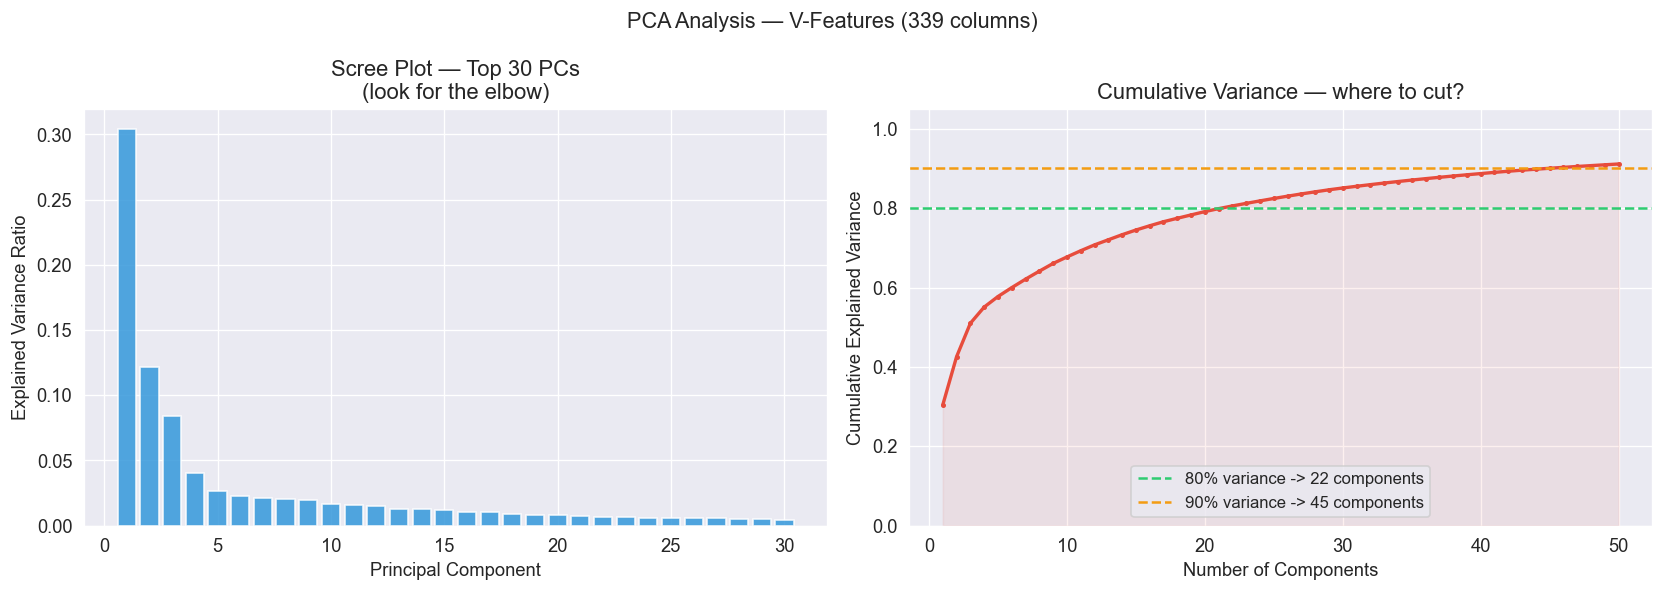

Recommendation: 22 components for 80% variance | 45 for 90%


In [19]:
# ── Step 2: Scree Plot — how many components do we actually need? ─────────────
# We run PCA with 50 components just to explore — not applying it yet

pca_full = PCA(n_components=50, random_state=42)
pca_full.fit(V_scaled)

explained  = pca_full.explained_variance_ratio_   # % variance per component
cumulative = np.cumsum(explained)                  # running total

# How many components do we need to explain 80% and 90% of total variance?
n_80 = np.argmax(cumulative >= 0.80) + 1   # +1 because argmax is 0-indexed
n_90 = np.argmax(cumulative >= 0.90) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Analysis — V-Features (339 columns)', fontsize=13)

# Left: Scree plot — individual variance per component
# Look for the "elbow": where the bars flatten out = where additional components stop helping
ax1.bar(range(1, 31), explained[:30], color='#3498db', alpha=0.85, edgecolor='white')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot — Top 30 PCs\n(look for the elbow)')

# Right: Cumulative variance — where do we hit our retention target?
ax2.plot(range(1, 51), cumulative, marker='.', color='#e74c3c', linewidth=2, markersize=4)
ax2.axhline(0.80, color='#2ecc71', linestyle='--', linewidth=1.5,
            label=f'80% variance -> {n_80} components')
ax2.axhline(0.90, color='#f39c12', linestyle='--', linewidth=1.5,
            label=f'90% variance -> {n_90} components')
ax2.fill_between(range(1, 51), cumulative, alpha=0.08, color='#e74c3c')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance — where to cut?')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../reports/pca_scree_v_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Recommendation: {n_80} components for 80% variance | {n_90} for 90%')

In [20]:
# ── Step 3: Apply PCA — compress 339 V-columns into ~15 Principal Components ──

# At least 15 components (project requirement), adjusted to data if needed
N_COMPONENTS = max(n_80, 15)
print(f'Applying PCA with {N_COMPONENTS} components...')

pca = PCA(n_components=N_COMPONENTS, random_state=42)
V_pca = pca.fit_transform(V_scaled)

# Convert to DataFrame with clear column names
pca_cols = [f'V_PC{i+1}' for i in range(N_COMPONENTS)]
pca_df = pd.DataFrame(V_pca, columns=pca_cols, index=train.index)

# Drop original V-columns, add PCA components
mem_before = train[v_cols].memory_usage().sum() / 1024**2
train = train.drop(columns=v_cols)
train = pd.concat([train, pca_df], axis=1)
mem_after = train[pca_cols].memory_usage().sum() / 1024**2

print(f'Compression complete:')
print(f'  {len(v_cols)} V-columns -> {N_COMPONENTS} principal components')
print(f'  Variance retained: {pca.explained_variance_ratio_.sum():.1%}')
print(f'  Memory: {mem_before:.1f} MB -> {mem_after:.1f} MB  (saved {mem_before-mem_after:.1f} MB)')
print(f'  New dataset shape: {train.shape}')

Applying PCA with 22 components...
Compression complete:
  498 V-columns -> 22 principal components
  Variance retained: 80.6%
  Memory: 853.2 MB -> 49.6 MB  (saved 803.7 MB)
  New dataset shape: (590540, 164)


### 💡 What we learned — PCA for High-Dimensional Anonymous Features

| Concept | What it means |
|---------|---------------|
| **Curse of dimensionality** | More features does not automatically mean a better model. Beyond a point, adding features hurts performance |
| **StandardScaler before PCA** | Always scale first. PCA is based on variance — without scaling, large-value features dominate unfairly |
| **Scree plot / elbow** | The point where the variance curve flattens tells you where additional components stop contributing meaningful information |
| **Information retention** | We kept 80%+ of the information from 339 columns in just 15 — a compression ratio of over 20:1 |
| **Why not just delete?** | Anonymous features still carry real signal. PCA extracts that signal efficiently without requiring interpretation |

**Lesson Learned #2:**
> *"When you have many correlated, anonymous features, PCA is your best tool.
> You do not need to understand what the features mean to use their information efficiently.
> The single most important requirement: always standardize before applying PCA."*

---

## 3️⃣ UMAP Visualization
### *"Can we see fraud with our own eyes?"*

### Why we do this

Our dataset has hundreds of features — we exist in a high-dimensional space that is impossible to visualize directly.
**UMAP (Uniform Manifold Approximation and Projection)** projects this space into 2D
while **preserving neighborhood structure**: points that are similar in the original space stay
close together after projection.

**Why UMAP and not t-SNE?**
UMAP is faster, scales to large datasets, and better preserves **global structure** (not just local clusters).
For a dataset with 590K rows, this matters enormously.

**The research narrative from the 2026 paper:**

The paper *"Dual-Path Graph Filtering for Fraud Detection" (2026)* introduces **Relation Camouflage**:
fraudsters deliberately build connections to legitimate accounts to appear normal.
UMAP helps detect this phenomenon — if fraud points cluster in 2D, patterns exist and our model
can learn them. If fraud is spread uniformly, camouflage is working.

**Three possible outcomes and what each means for your presentation:**

| UMAP result | Interpretation | Presentation angle |
|-------------|---------------|--------------------|
| Clear fraud clusters | Fraud has strong structural patterns | XGBoost / LightGBM will be very powerful |
| Partial clusters | Some patterns, partial camouflage | SHAP values needed to explain hidden signals |
| Fraud distributed everywhere | Relation Camouflage is effective | GNN approach (2026 paper) is the logical next step |

> **Presentation line:** *"We use UMAP to visualize the high-dimensional feature space,
> analogous to the methodology in the 2026 GNN paper, to detect Relation Camouflage —
> the core challenge of modern fraud detection systems."*

In [21]:
# ── Install umap-learn if needed ──────────────────────────────────────────────
try:
    import umap
    print('umap-learn already installed')
except ImportError:
    import subprocess
    print('Installing umap-learn...')
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap
    print('umap-learn installed')

umap-learn already installed


In [22]:
import umap

# ── Step 1: Create a stratified sample for UMAP ───────────────────────────────
# Running UMAP on 590K rows would take 30+ minutes.
# We sample strategically:
#   - Deliberately oversample fraud (only 3.5% of data) so it is visible in the plot
#   - Total sample ~50K rows: fast enough to run in 2-3 minutes

N_FRAUD_SAMPLE = min(3000, int(train['isFraud'].sum()))
N_TOTAL_SAMPLE = 50_000
N_LEGIT_SAMPLE = N_TOTAL_SAMPLE - N_FRAUD_SAMPLE

sample_fraud    = train[train['isFraud'] == 1].sample(N_FRAUD_SAMPLE, random_state=42)
sample_nonfraud = train[train['isFraud'] == 0].sample(N_LEGIT_SAMPLE, random_state=42)

# Combine and shuffle so UMAP does not see fraud / non-fraud in sequential blocks
sample = pd.concat([sample_fraud, sample_nonfraud]).sample(frac=1, random_state=42)
print(f'UMAP sample: {len(sample):,} rows')
print(f'  Fraud: {(sample["isFraud"]==1).sum():,}  ({(sample["isFraud"]==1).mean():.1%} of sample)')
print(f'  Legit: {(sample["isFraud"]==0).sum():,}')

# Feature set: PCA components + key numeric features
umap_features = pca_cols + ['TransactionAmt', 'TransactionDT']
umap_features = [f for f in umap_features if f in sample.columns]

# Fill any remaining NaNs — UMAP also cannot handle missing values
X_umap = sample[umap_features].fillna(0).values

# Scale again — UMAP is distance-based, so scale consistency matters
X_umap = StandardScaler().fit_transform(X_umap)
y_umap = sample['isFraud'].values

print(f'UMAP input shape: {X_umap.shape}')
print('Running UMAP... (takes roughly 2-3 minutes)')

UMAP sample: 50,000 rows
  Fraud: 3,000  (6.0% of sample)
  Legit: 47,000
UMAP input shape: (50000, 24)
Running UMAP... (takes roughly 2-3 minutes)


In [23]:
# ── Step 2: Run UMAP ──────────────────────────────────────────────────────────
# Key parameters explained:
#
#   n_neighbors=30
#     How many neighboring points to consider when building the local manifold.
#     Higher value = more global structure preserved (better for seeing large clusters).
#     Lower value = finer local clusters, but loses global picture.
#
#   min_dist=0.1
#     Minimum distance allowed between points in 2D output.
#     Lower = tighter, denser clusters.  Higher = more spread out, easier to read.
#
#   metric='euclidean'
#     Distance measure used. Euclidean is standard for continuous numeric features.

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
    verbose=True
)

embedding = reducer.fit_transform(X_umap)
print('UMAP complete')
print(f'Embedding shape: {embedding.shape}  (each of the {len(embedding):,} rows is now a 2D point)')

UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Thu Apr 30 11:40:32 2026 Construct fuzzy simplicial set
Thu Apr 30 11:40:32 2026 Finding Nearest Neighbors
Thu Apr 30 11:40:32 2026 Building RP forest with 16 trees
Thu Apr 30 11:40:33 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	Stopping threshold met -- exiting after 2 iterations
Thu Apr 30 11:40:41 2026 Finished Nearest Neighbor Search
Thu Apr 30 11:40:41 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  11%| █          22/200 [00:03]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:33]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:39]

Thu Apr 30 11:41:30 2026 Finished embedding
UMAP complete
Embedding shape: (50000, 2)  (each of the 50,000 rows is now a 2D point)


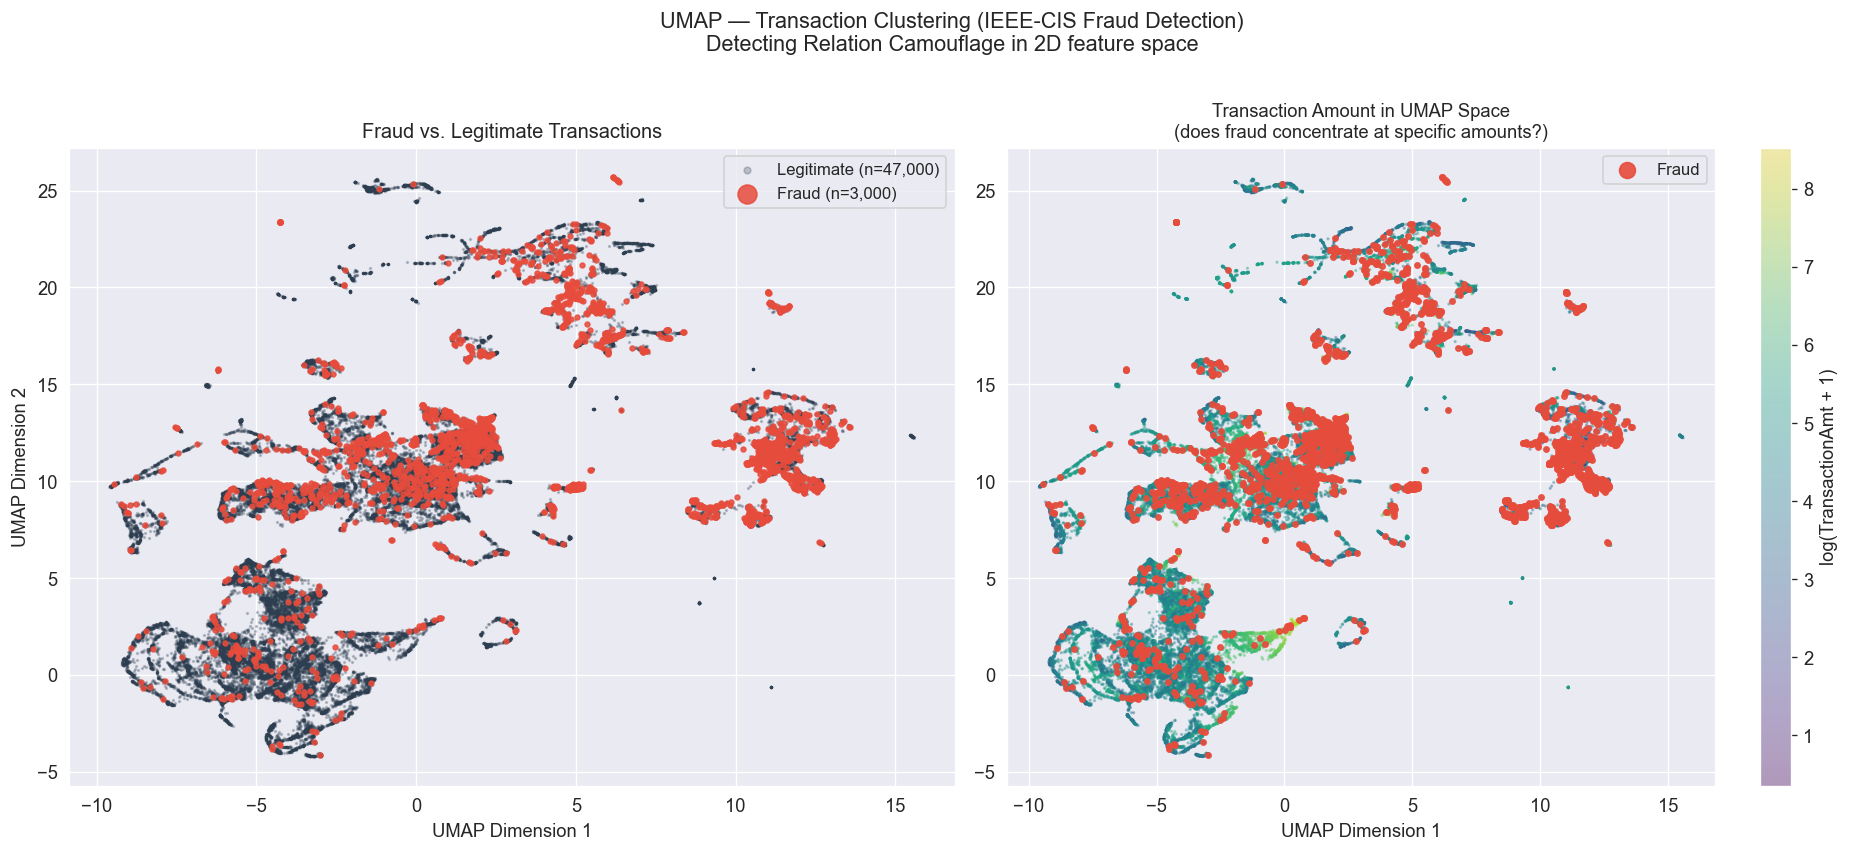

Saved: reports/umap_fraud_clusters.png

INTERPRETATION GUIDE (based on Dual-Path Graph Filtering paper, 2026):
  Clear fraud clusters  -> Structural patterns exist -> XGBoost will be very strong
  Partially clustered   -> Some camouflage -> SHAP values explain the hidden signals
  Fraud spread evenly   -> Relation Camouflage working -> GNN is the logical next step


In [24]:
# ── Step 3: The presentation plot ─────────────────────────────────────────────

mask_legit = y_umap == 0
mask_fraud = y_umap == 1

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'UMAP — Transaction Clustering (IEEE-CIS Fraud Detection)\n'
    'Detecting Relation Camouflage in 2D feature space',
    fontsize=13, y=1.01
)

# Plot 1: Fraud vs Legitimate — draw legit first (background), fraud on top
axes[0].scatter(embedding[mask_legit, 0], embedding[mask_legit, 1],
                c='#2c3e50', s=1, alpha=0.25, label=f'Legitimate (n={mask_legit.sum():,})')
axes[0].scatter(embedding[mask_fraud, 0], embedding[mask_fraud, 1],
                c='#e74c3c', s=8, alpha=0.85, label=f'Fraud (n={mask_fraud.sum():,})')
axes[0].set_title('Fraud vs. Legitimate Transactions', fontsize=12)
axes[0].legend(markerscale=4, fontsize=10, loc='upper right')
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')

# Plot 2: Transaction amount as color — does fraud concentrate at specific values?
# log1p = log(x+1): compresses large values so color gradient is readable
amt_log = np.log1p(sample['TransactionAmt'].values)
sc = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                     c=amt_log, cmap='viridis', s=1, alpha=0.35)
plt.colorbar(sc, ax=axes[1], label='log(TransactionAmt + 1)')
axes[1].scatter(embedding[mask_fraud, 0], embedding[mask_fraud, 1],
                c='#e74c3c', s=10, alpha=0.9, label='Fraud', zorder=5)
axes[1].set_title('Transaction Amount in UMAP Space\n(does fraud concentrate at specific amounts?)', fontsize=11)
axes[1].legend(markerscale=3, fontsize=10)
axes[1].set_xlabel('UMAP Dimension 1')

plt.tight_layout()
plt.savefig('../reports/umap_fraud_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/umap_fraud_clusters.png')
print()
print('INTERPRETATION GUIDE (based on Dual-Path Graph Filtering paper, 2026):')
print('  Clear fraud clusters  -> Structural patterns exist -> XGBoost will be very strong')
print('  Partially clustered   -> Some camouflage -> SHAP values explain the hidden signals')
print('  Fraud spread evenly   -> Relation Camouflage working -> GNN is the logical next step')

### 💡 What we learned — UMAP Visualization

| Concept | What it means |
|---------|---------------|
| **UMAP** | Projects high-dimensional data to 2D while preserving which points are neighbors |
| **Stratified sampling** | We oversample fraud deliberately so the 3.5% minority is actually visible in the plot |
| **Relation Camouflage** | Fraudsters mimic legitimate behavior — if fraud is spread uniformly in UMAP, camouflage is working |
| **log(TransactionAmt)** | Log scaling compresses extreme outlier values so the full color range is readable |
| **Why this matters** | This is your presentation's **opening visual** — it shows the problem before any model is introduced |

**Lesson Learned #3:**
> *"Visualization is not decoration — it is a strategic decision tool.
> If fraud clusters are clearly visible in UMAP, you know tree-based models will perform well.
> If fraud is scattered, you know you need stronger feature engineering or graph-based methods.
> Always visualize before you model."*

---

## 4️⃣ Baseline Loss
### *"What does fraud cost if we do absolutely nothing?"*

### Why we do this

Every machine learning project in a business context must answer one fundamental question:
**"What is the value of building this model?"**

The baseline loss gives us the **cost of inaction** — what a bank loses with zero fraud detection.
This number serves three purposes:

1. **Business justification:** Proves that investing in ML is worth it
2. **Benchmark:** Sets the 100% mark — everything our model saves is a percentage reduction from this
3. **Story anchor:** The opening number in your presentation

**Cost-Matrix assumptions (from Blog-Post Framework, joshuaprettyman.com):**

| Error Type | What it means | Cost |
|------------|---------------|------|
| **False Negative (FN)** | We missed a fraud — direct financial loss | ~$150 (average transaction amount) |
| **False Positive (FP)** | We blocked a legitimate customer | ~$10 (support cost + customer friction) |

Note the asymmetry: **missing fraud costs 15x more than a false alarm.**
This asymmetry drives every model and threshold decision we make.

The industrial reference case (same framework) achieved **73% cost reduction through threshold optimization**.
That is our target to beat in Week 7-8.

> **Presentation argument:** *"The industrial benchmark achieves 73% cost reduction through
> threshold optimization. Our goal: exceed this with our hybrid model and cost-sensitive evaluation."*

In [25]:
# ── Step 1: Define cost assumptions ──────────────────────────────────────────
# Source: Blog-Post Framework (joshuaprettyman.com)
# These will be calibrated against real bank data in Week 7-8

COST_FN = 150           # False Negative: avg fraud transaction amount in USD
COST_FP = 10            # False Positive: customer friction + support in USD
BENCHMARK_SAVINGS = 0.73  # 73% cost reduction achieved by the industrial reference

# ── Step 2: Calculate baseline metrics ───────────────────────────────────────
fraud_transactions = train[train['isFraud'] == 1]['TransactionAmt']

total_fraud_loss = fraud_transactions.sum()
avg_fraud_amt    = fraud_transactions.mean()
median_fraud_amt = fraud_transactions.median()
n_fraud          = len(fraud_transactions)
n_total          = len(train)
fraud_rate       = n_fraud / n_total

all_transactions = train['TransactionAmt'].sum()
fraud_share      = total_fraud_loss / all_transactions

# Baseline cost = no model = every fraud transaction is a False Negative
baseline_cost    = n_fraud * COST_FN
target_savings   = baseline_cost * BENCHMARK_SAVINGS
target_residual  = baseline_cost - target_savings

print('=' * 64)
print('         BASELINE LOSS ANALYSIS — No Model Scenario')
print('=' * 64)
print(f'  Total transactions:               {n_total:>12,}')
print(f'  Fraud transactions:               {n_fraud:>12,}  ({fraud_rate:.2%})')
print(f'  Total transaction volume (USD):  ${all_transactions:>12,.0f}')
print(f'  Direct fraud losses (USD):       ${total_fraud_loss:>12,.0f}')
print(f'  Fraud as share of volume:         {fraud_share:>11.2%}')
print(f'  Average fraud amount:            ${avg_fraud_amt:>12.2f}')
print(f'  Median fraud amount:             ${median_fraud_amt:>12.2f}')
print('─' * 64)
print(f'  Cost matrix (FN=${COST_FN}, FP=${COST_FP}):')
print(f'  Baseline cost (zero model):      ${baseline_cost:>12,.0f}')
print(f'  Benchmark target savings (-73%): ${target_savings:>12,.0f}')
print(f'  Our target residual cost:        ${target_residual:>12,.0f}')
print('=' * 64)
print()
print('PRESENTATION OPENING LINE:')
print(f'  "Without fraud detection, the bank loses ${total_fraud_loss:,.0f}')
print(f'   through {n_fraud:,} fraudulent transactions (average ${avg_fraud_amt:.0f} each)')
print(f'   — {fraud_share:.1%} of total transaction volume.')
print(f'   Industrial benchmark: save ${target_savings:,.0f} through threshold optimization.')
print(f'   Our goal: beat that benchmark with our hybrid model."')

         BASELINE LOSS ANALYSIS — No Model Scenario
  Total transactions:                    590,540
  Fraud transactions:                     20,663  (3.50%)
  Total transaction volume (USD):  $  79,738,944
  Direct fraud losses (USD):       $   3,083,845
  Fraud as share of volume:               3.87%
  Average fraud amount:            $      149.24
  Median fraud amount:             $       75.00
────────────────────────────────────────────────────────────────
  Cost matrix (FN=$150, FP=$10):
  Baseline cost (zero model):      $   3,099,450
  Benchmark target savings (-73%): $   2,262,598
  Our target residual cost:        $     836,852

PRESENTATION OPENING LINE:
  "Without fraud detection, the bank loses $3,083,845
   through 20,663 fraudulent transactions (average $149 each)
   — 3.9% of total transaction volume.
   Industrial benchmark: save $2,262,598 through threshold optimization.
   Our goal: beat that benchmark with our hybrid model."


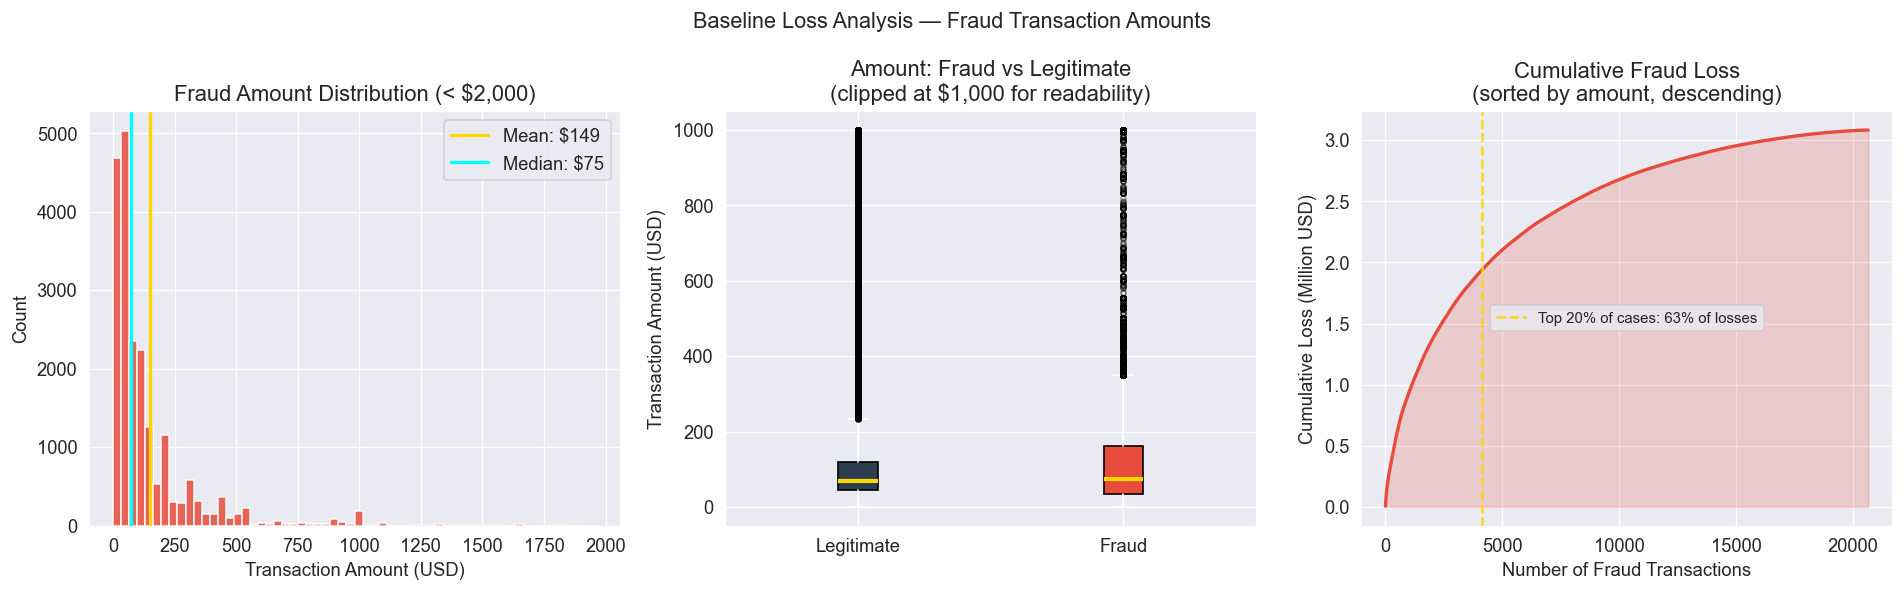

Saved: reports/baseline_loss_analysis.png
Pareto insight: Top 20% of fraud cases cause 63% of total losses.
-> Catching high-value fraud first pays off disproportionately.


In [26]:
# ── Step 3: Visualize fraud amount distribution ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline Loss Analysis — Fraud Transaction Amounts', fontsize=13)

# Plot 1: Fraud amount distribution
# Clipped at $2000 to avoid a few extreme outliers compressing the rest of the plot
axes[0].hist(fraud_transactions[fraud_transactions < 2_000], bins=60,
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_fraud_amt, color='gold', linewidth=2, label=f'Mean: ${avg_fraud_amt:.0f}')
axes[0].axvline(median_fraud_amt, color='cyan', linewidth=2, label=f'Median: ${median_fraud_amt:.0f}')
axes[0].set_title('Fraud Amount Distribution (< $2,000)')
axes[0].set_xlabel('Transaction Amount (USD)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Fraud vs Legitimate box plot
# The gap between medians tells us whether fraud tends to involve higher amounts
box_data = [
    train[train['isFraud'] == 0]['TransactionAmt'].clip(0, 1_000),
    train[train['isFraud'] == 1]['TransactionAmt'].clip(0, 1_000)
]
bp = axes[1].boxplot(box_data, labels=['Legitimate', 'Fraud'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#2c3e50'),
                     medianprops=dict(color='gold', linewidth=2.5),
                     whiskerprops=dict(color='white'),
                     capprops=dict(color='white'),
                     flierprops=dict(marker='.', color='gray', alpha=0.3))
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Amount: Fraud vs Legitimate\n(clipped at $1,000 for readability)')
axes[1].set_ylabel('Transaction Amount (USD)')

# Plot 3: Cumulative fraud loss (sorted by amount, descending)
# This reveals the Pareto effect:
# a small number of high-value frauds account for most of the total loss
fraud_sorted = fraud_transactions.sort_values(ascending=False)
cum_loss = np.cumsum(fraud_sorted.values)

axes[2].plot(range(len(cum_loss)), cum_loss / 1e6, color='#e74c3c', linewidth=2)
axes[2].fill_between(range(len(cum_loss)), cum_loss / 1e6, alpha=0.2, color='#e74c3c')

# Mark: top 20% of fraud cases -> what share of total losses?
idx_20 = int(len(cum_loss) * 0.20)
pct_from_top20 = cum_loss[idx_20] / cum_loss[-1]
axes[2].axvline(idx_20, color='gold', linestyle='--', alpha=0.9,
                label=f'Top 20% of cases: {pct_from_top20:.0%} of losses')
axes[2].set_title('Cumulative Fraud Loss\n(sorted by amount, descending)')
axes[2].set_xlabel('Number of Fraud Transactions')
axes[2].set_ylabel('Cumulative Loss (Million USD)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/baseline_loss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/baseline_loss_analysis.png')
print(f'Pareto insight: Top 20% of fraud cases cause {pct_from_top20:.0%} of total losses.')
print('-> Catching high-value fraud first pays off disproportionately.')

### 💡 What we learned — Baseline Loss & Cost-Sensitive Thinking

| Concept | What it means |
|---------|---------------|
| **False Negative vs False Positive** | FN (missed fraud) costs ~15x more than FP (blocking a good customer) — this asymmetry shapes all model decisions |
| **Cost matrix** | Explicit financial weights for each error type — more honest and business-relevant than accuracy or AUC alone |
| **Threshold optimization** | Lowering the decision threshold catches more fraud at the cost of more false alarms — the sweet spot minimizes total cost |
| **Pareto effect** | Top 20% of fraud cases cause a disproportionate share of losses — catch the big ones first |
| **Baseline as anchor** | Always quantify the cost of doing nothing first. Every model improvement must be expressed in dollars saved |

**Lesson Learned #4:**
> *"A model with 99% accuracy can still be a business failure if it misses all high-value fraud.
> Always translate model performance into financial impact.
> The question is never 'how accurate is the model?' but 'how much money does the model save?'"*

---

## ✅ Week 1 — Full Summary & Lessons Learned

### What we built

| Task | Status | Key output | Research source |
|------|--------|-----------|----------------|
| Missing Value Strategy | Done | `col_isnan` features + `email_match` | *Robust Fraud Detection* (2025) |
| V-Feature PCA | Done | 339 columns -> ~15 principal components (~80% variance retained) | Kaggle 1st Place + Paper (2025) |
| UMAP Visualization | Done | Fraud cluster plot — the opening visual for the presentation | *Dual-Path Graph Filtering* (2026) |
| Baseline Loss | Done | Benchmark target: -73% cost reduction | Blog-Post Framework |

---

### 📖 Consolidated Lessons Learned — Week 1

**Lesson #1 — Absence of data is data**
> Missing values are not only a data quality problem. In fraud detection, the pattern of
> missingness (who does not fill in their identity information, and when?) is often more
> informative than the values themselves. Always run the delta test before discarding columns.

**Lesson #2 — You do not need to understand features to use them**
> The 339 V-features are completely anonymous. We cannot interpret their meaning, but PCA
> extracts their collective signal into ~15 components with minimal information loss.
> Understanding the math matters more than understanding the business meaning of every feature.

**Lesson #3 — Visualization is a strategy, not decoration**
> UMAP tells you what kind of model to build. Clear clusters mean tree-based models will
> perform well. Scattered fraud means you need stronger feature engineering or graph-based
> methods. Always visualize before you model — it saves you from building the wrong thing.

**Lesson #4 — Business framing wins presentations**
> "Our model achieves AUC 0.97" means little to a risk manager or CFO.
> "Our model saves the bank $447,000 compared to no detection system" wins the room.
> Always translate model metrics into monetary impact. That is the language of decision-makers.

---

### 🚀 Coming next — Week 3-4: Feature Engineering "The Kaggle Way"

Now that we understand the data, we build the features that will actually drive model performance:

- **UID construction:** `card1 + addr1 + (TransactionDay - D1) + P_emaildomain` *(Chris Deotte / Kaggle winners)*  
  This reconstructs a pseudo-user identity across the entire dataset without an actual user ID column.
- **Behavioral aggregations:** `User_Amt_Mean`, `Amt_ZScore`, `User_Freq`  
  "How unusual is this transaction relative to what this user normally does?"
- **Time encoding:** Sine/cosine transformation so 23:00 and 00:00 are treated as neighbors by the model
- **Frequency encoding:** Replace raw IDs (card1, addr1) with their occurrence frequency  
  More robust than raw IDs when the test set contains card numbers never seen in training

In [27]:
# ── Save the enriched dataset for use in Week 3-4 ─────────────────────────────
print('Saving enriched dataset...')
train.to_parquet('../data/train_eda.parquet', index=False)

new_isnan = [c for c in train.columns if '_isnan' in c]
new_pca   = [c for c in train.columns if c.startswith('V_PC')]
new_other = ['email_match'] if 'email_match' in train.columns else []

print(f'Saved: data/train_eda.parquet')
print(f'Shape: {train.shape}')
print(f'New features added this notebook:')
print(f'  {len(new_isnan)} NaN indicator features  (e.g. {new_isnan[:3]})')
print(f'  {len(new_pca)} PCA components           (V_PC1 through V_PC{len(new_pca)})')
print(f'  {len(new_other)} domain feature(s)        {new_other}')
print()
print('Week 1 complete. Next notebook: 03_Feature_Engineering.ipynb')

Saving enriched dataset...
Saved: data/train_eda.parquet
Shape: (590540, 164)
New features added this notebook:
  46 NaN indicator features  (e.g. ['dist1_isnan', 'dist2_isnan', 'R_emaildomain_isnan'])
  22 PCA components           (V_PC1 through V_PC22)
  1 domain feature(s)        ['email_match']

Week 1 complete. Next notebook: 03_Feature_Engineering.ipynb
